In [2]:
import pandas as pd

df = pd.read_csv("../data/sales_dataset.csv")
df.head()

,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Column1
0,0,2/19/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,1.0,80.00,109.000000,80.0,109.0,NaN
1,1,2/20/2016,2016.0,February,29.0,F,United States,Washington,Clothing,Gloves,2.0,24.50,28.500000,49.0,57.0,NaN
2,2,2/27/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,3.67,5.000000,11.0,15.0,NaN
3,3,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,87.50,116.500000,175.0,233.0,NaN
4,4,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,35.00,41.666667,105.0,125.0,NaN


In [3]:
df.shape

(34867, 16)

In [4]:
df.dtypes

index                 int64
Date                    str
Year                float64
Month                   str
Customer Age        float64
Customer Gender         str
Country                 str
State                   str
Product Category        str
Sub Category            str
Quantity            float64
Unit Cost           float64
Unit Price          float64
Cost                float64
Revenue             float64
Column1             float64
dtype: object

In [5]:
#Missing values
df.isnull().sum()

index                   0
Date                    1
Year                    1
Month                   1
Customer Age            1
Customer Gender         1
Country                 1
State                   1
Product Category        1
Sub Category            1
Quantity                1
Unit Cost               1
Unit Price              1
Cost                    1
Revenue                 0
Column1             32293
dtype: int64

In [6]:
#Data cleaning
df_duplicate = df.copy()
df.duplicated().sum()

np.int64(0)

In [7]:
#Removing duplicates
df_duplicate_removed = df_duplicate.drop_duplicates()

In [8]:
df_missing = df.copy()
df_missing = df.fillna(df.mean(numeric_only = True))
#df_missing = df.fillna(df.median(numerics_only = True))

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34867 entries, 0 to 34866
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             34867 non-null  int64         
 1   Date              34866 non-null  datetime64[us]
 2   Year              34866 non-null  float64       
 3   Month             34866 non-null  str           
 4   Customer Age      34866 non-null  float64       
 5   Customer Gender   34866 non-null  str           
 6   Country           34866 non-null  str           
 7   State             34866 non-null  str           
 8   Product Category  34866 non-null  str           
 9   Sub Category      34866 non-null  str           
 10  Quantity          34866 non-null  float64       
 11  Unit Cost         34866 non-null  float64       
 12  Unit Price        34866 non-null  float64       
 13  Cost              34866 non-null  float64       
 14  Revenue           34867 non-null 

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby(df['Date'].dt.month)['Revenue'].sum()
print(monthly_sales)

Date
1.0     1950621.0
2.0     1994233.0
3.0     2135336.0
4.0     2200490.0
5.0     2625820.0
6.0     2681985.0
7.0     1280666.0
8.0     1248185.0
9.0     1295246.0
10.0    1376969.0
11.0    1438928.0
12.0    2116097.0
Name: Revenue, dtype: float64


In [12]:
#EDA

df = df.sort_values(by='Date')
daily_sales = df.groupby('Date')['Revenue'].sum()

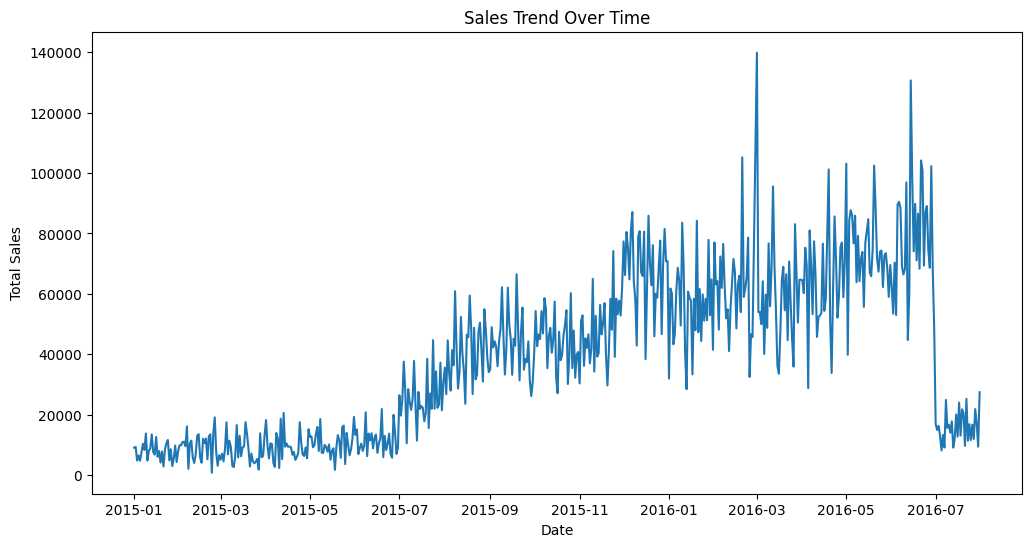

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(daily_sales)

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

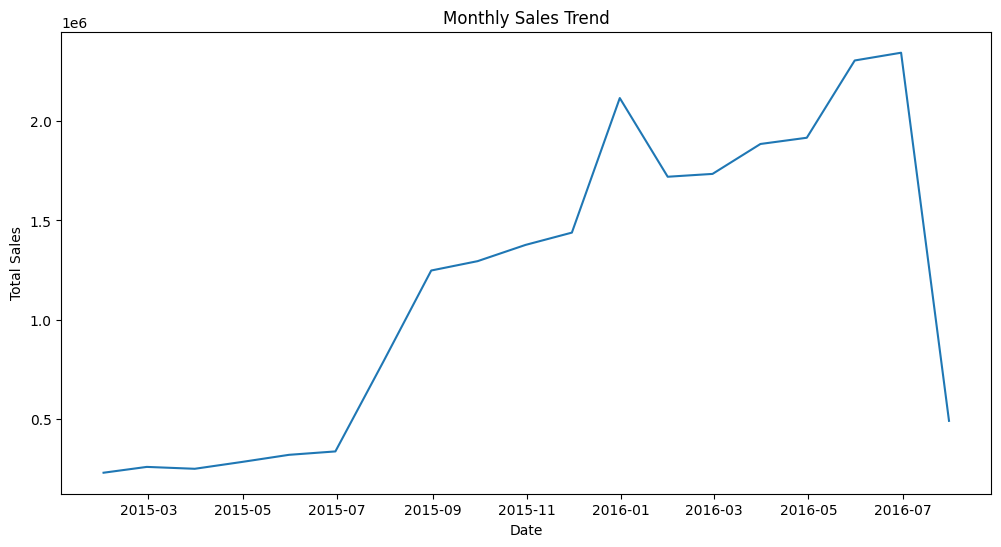

In [14]:
#Better version
import matplotlib.pyplot as plt
monthly_sales = df.resample('ME', on='Date')['Revenue'].sum()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

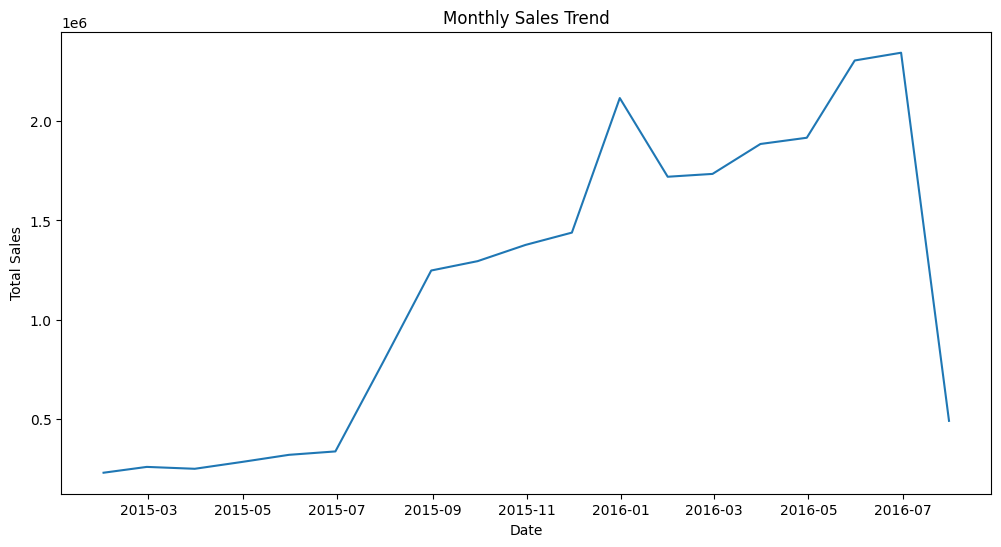

In [15]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

A time series analysis was performed to observe how sales changed over time. Sales values were aggregated by date and plotted using a line graph. The visualization helps identify patterns such as seasonal variations, increasing or decreasing sales trends, and potential fluctuations in revenue over different periods.

In [43]:
df["Profit"] = df["Revenue"] - df["Cost"]
df["Discount"] = (df["Unit Price"] - df["Unit Cost"])/df["Unit Price"]*100

df.head()


,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Column1,Profit,Discount,discount
12252,12252,2015-01-01,2015.0,1.0,37.0,F,Germany,Hamburg,Bikes,Road Bikes,2.0,1091.0,1272.500000,2182.0,2545.0,NaN,363.0,14.263261,-14.263261
2150,2150,2015-01-01,2015.0,1.0,19.0,F,United States,Washington,Bikes,Road Bikes,1.0,1000.0,938.000000,1000.0,938.0,214.0,-62.0,-6.609808,6.609808
9857,9857,2015-01-01,2015.0,1.0,29.0,F,United States,Florida,Bikes,Road Bikes,3.0,261.0,230.666667,783.0,692.0,NaN,-91.0,-13.150289,13.150289
9859,9859,2015-01-01,2015.0,1.0,29.0,M,United States,Oregon,Bikes,Road Bikes,3.0,261.0,233.000000,783.0,699.0,NaN,-84.0,-12.017167,12.017167
9687,9687,2015-01-01,2015.0,1.0,36.0,F,United States,California,Bikes,Mountain Bikes,2.0,1035.5,896.000000,2071.0,1792.0,NaN,-279.0,-15.569196,15.569196


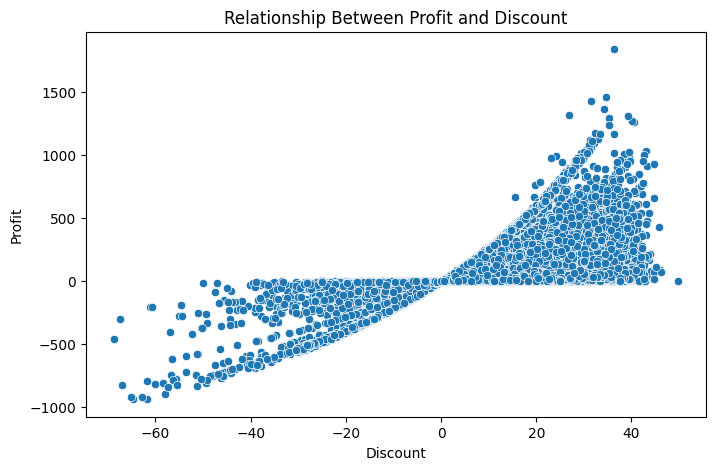

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(x='Discount', y='Profit', data=df)

plt.title("Relationship Between Profit and Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

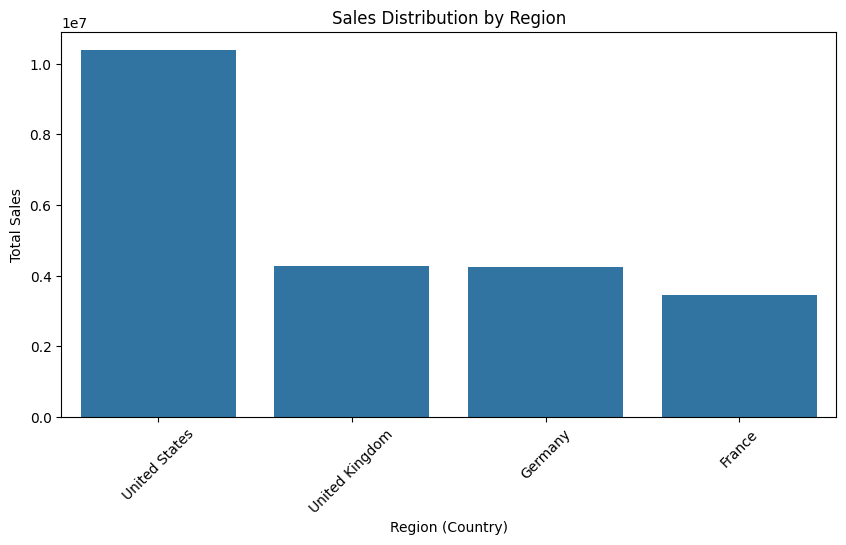

In [45]:
#Bar plots and pie plots 
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

region_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=region_sales.index, y=region_sales.values)

plt.title("Sales Distribution by Region")
plt.xlabel("Region (Country)")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

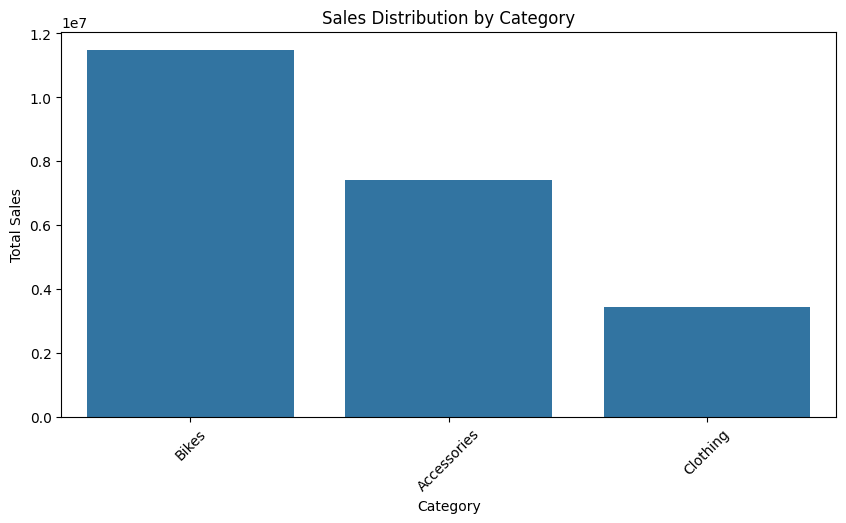

In [46]:
#Bar plots and pie plots 
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

cat_sales = df.groupby('Product Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=cat_sales.index, y=cat_sales.values)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

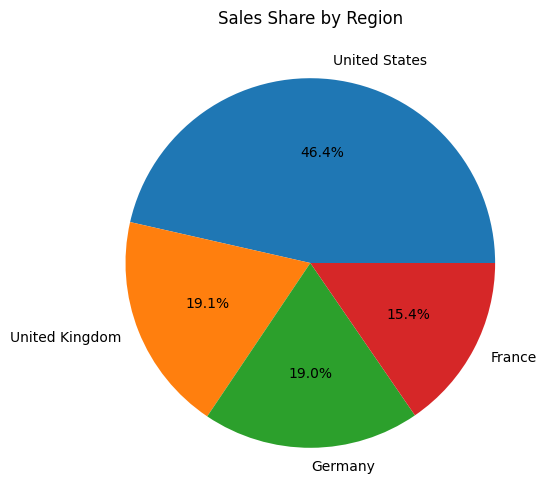

In [47]:
#Pie plots and pie plots 
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

region_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))

plt.pie(region_sales.values,
        labels=region_sales.index,
        autopct='%1.1f%%')

plt.title("Sales Share by Region")

plt.show()

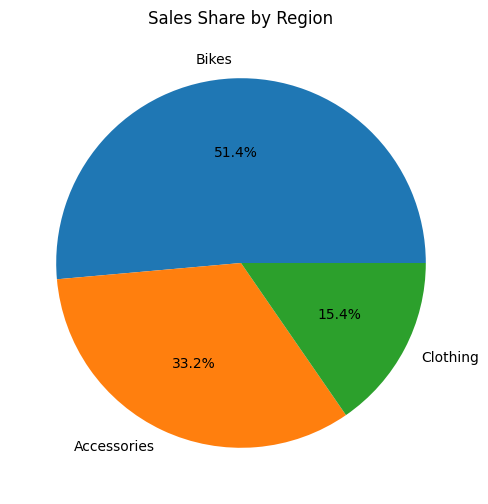

In [48]:
#Pie plots and pie plots 
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

cat_sales = df.groupby('Product Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))

plt.pie(cat_sales.values,
        labels=cat_sales.index,
        autopct='%1.1f%%')

plt.title("Sales Share by Region")

plt.show()

In [49]:
#Missing values
df.isnull().sum()

index                   0
Date                    1
Year                    1
Month                   1
Customer Age            1
Customer Gender         1
Country                 1
State                   1
Product Category        1
Sub Category            1
Quantity                1
Unit Cost               1
Unit Price              1
Cost                    1
Revenue                 0
Column1             32293
Profit                  1
Discount                1
discount                0
dtype: int64

In [50]:
df["Profit"] = df["Profit"].fillna(df["Profit"].mean())
df["Discount"] = df["Discount"].fillna(df["Discount"].mean())

In [51]:
#Missing values
df.isnull().sum()

index                   0
Date                    1
Year                    1
Month                   1
Customer Age            1
Customer Gender         1
Country                 1
State                   1
Product Category        1
Sub Category            1
Quantity                1
Unit Cost               1
Unit Price              1
Cost                    1
Revenue                 0
Column1             32293
Profit                  0
Discount                0
discount                0
dtype: int64

In [52]:
X = df[['Profit','Discount']]
y = df['Revenue']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

MSE: 297380.73503592995
R2 Score: 0.4433124699292089
Intercept: 871.9852577294212
Coefficients: [  3.61328783 -34.57672225]


A Linear Regression model was trained to predict sales (Revenue) using Profit and Discount as input features. The dataset was split into training and testing sets to evaluate model performance. The model was assessed using Mean Squared Error (MSE) and R² score. The results indicate that Profit has a strong influence on sales, while Discount shows an inverse relationship, highlighting the impact of pricing strategies on revenue.

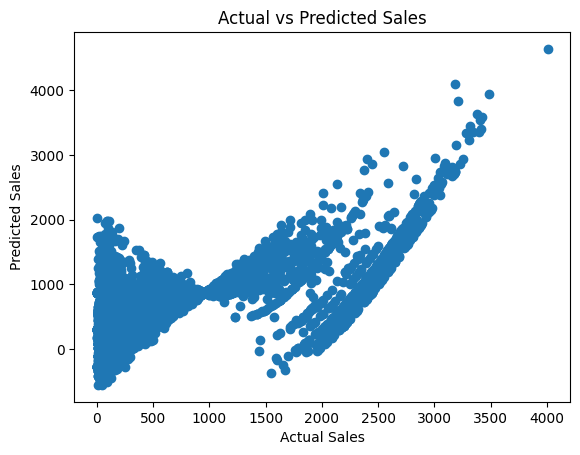

In [53]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [54]:
model.predict([[200, 0.1]])

C:\Users\Rishabh Singh\MainFlowDSProjects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1591.18515056])

In [55]:
model.predict([[200, 13]])

C:\Users\Rishabh Singh\MainFlowDSProjects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1145.14543359])

In [56]:
model.predict([[200, -13]])

C:\Users\Rishabh Singh\MainFlowDSProjects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2044.14021198])

In [57]:
model.predict([[600, -40]])

C:\Users\Rishabh Singh\MainFlowDSProjects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4423.02684273])

In [58]:
model.predict([[1000, 30]])

C:\Users\Rishabh Singh\MainFlowDSProjects\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3447.97141564])

## Key Insights

### 1.Impact of Discount on Profit
Analysis shows that higher discount levels are generally associated with lower profits. Several transactions with high discounts resulted in negative profit values, indicating that excessive discounting can harm overall profitability.

### 2.Top Performing Product Categories
Certain product categories, such as Bikes, contribute significantly to total revenue compared to others. This suggests strong customer demand and higher sales volume in these categories.

### 3.Regional Sales Performance
Sales distribution across regions indicates that some countries or states contribute more significantly to total revenue. These regions represent high-performing markets and key revenue drivers.

### 4.Revenue Drivers
Revenue is strongly influenced by both unit price and quantity sold. High-value transactions and bulk purchases contribute significantly to overall sales.

### 5.Presence of Loss-Making Transactions
Some transactions show negative profit, indicating that products were sold below cost. This may be due to heavy discounting or inefficient pricing strategies.

## Recommendations

### 1.Optimize Discount Strategy
Avoid offering excessive discounts that lead to negative profits. Implement controlled discount ranges to balance customer attraction and profitability.

### 2.Focus on High-Performing Categories
Increase marketing efforts and inventory availability for top-performing categories such as Bikes to maximize revenue.

### 3.Target High-Revenue Regions
Invest more in regions with strong sales performance through promotions, better distribution, and localized strategies.

### 4.Reduce Loss-Making Sales
Identify and minimize transactions where revenue is lower than cost. Implement pricing checks to ensure sustainable profit margins.

### 5.Leverage Customer Segmentation
Use clustering results to identify high-value customers and tailor marketing strategies accordingly, such as personalized offers for high spenders.